In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import traceback
from pathlib import Path

from IPython.display import clear_output
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import r2_score
from matplotlib.colors import LogNorm

In [ ]:
hist_path = Path(".") / "hists"
hist_path

In [ ]:
n_train = 75
n_test = 25


hists = []
reduced_hists = []

i = 0
j = 0
while i < n_train + n_test:
    hist = np.load(hist_path + os.sep + f"hist{i+j}.npy")
    solo_cov = load_random_file("coverages/solo")
    try:
        reduced_hist = np.where(solo_cov, hist, np.nan)
        hists.append(hist)
        reduced_hists.append(reduced_hist)
        i += 1
    except ValueError:
        print(traceback.format_exc())
        j += 1
        continue
        
hists = np.vstack(hists)
reduced = np.vstack(reduced_hists)

train = hists[:n_train*720]
test = reduced[n_train*720:]
true = hists[n_train*720:]

#model = pickle.load(open('knnimputer_20251207', 'rb'))

In [ ]:
model = KNNImputer(n_neighbors=5, weights="distance")
model.fit(train)
dump_file = open('knnimputer_20251207_75_25', 'wb')
pickle.dump(model, dump_file)
dump_file.close()

In [ ]:
model = pickle.load(open("knnimputer_20251207_75_25", "rb"))

In [ ]:
test1 = model.transform(test[9*720:10*720])
true1 = true[9*720:10*720, :-1]    # for some reason one angle bin gets left out
reduced = test[9*720:10*720, :-1]
X1, Y1 = np.meshgrid(np.arange(0, test1.shape[0]), np.arange(0, test1.shape[1]), indexing="ij")
X2, Y2 = np.meshgrid(np.arange(0, true1.shape[0]), np.arange(0, true1.shape[1]), indexing="ij")
pred = np.where((np.isnan(reduced) & np.isfinite(true1)), test1, np.nan)
target = np.where(np.isfinite(pred), true1, np.nan)

In [ ]:
fig, axs = plt.subplots(nrows=5, figsize=(16,20))
hist_min = np.nanmin(np.vstack([test1, true1]))
hist_max = np.nanmax(np.vstack([test1, true1]))
axs[0].pcolormesh(X2, Y2, true1, norm=LogNorm(hist_min, hist_max), cmap="inferno")
axs[0].set_title("Wind intensities")
axs[1].pcolormesh(X2, Y2, reduced, norm=LogNorm(hist_min, hist_max), cmap="inferno")
axs[1].set_title("Wind intensities w/ reduction")
axs[2].pcolormesh(X2, Y2, test1, norm=LogNorm(hist_min, hist_max), cmap="inferno")
axs[2].set_title(f"k-NN imputed values, k = {5}")
axs[3].pcolormesh(X2, Y2, pred, norm=LogNorm(hist_min, hist_max), cmap="inferno")
axs[3].set_title("Predicted values")
axs[4].pcolormesh(X2, Y2, target, norm=LogNorm(hist_min, hist_max), cmap="inferno")
axs[4].set_title("Target values")

In [ ]:
target = target.flatten()
pred = pred.flatten()
r2_score(target[np.isfinite(target)], pred[np.isfinite(pred)])

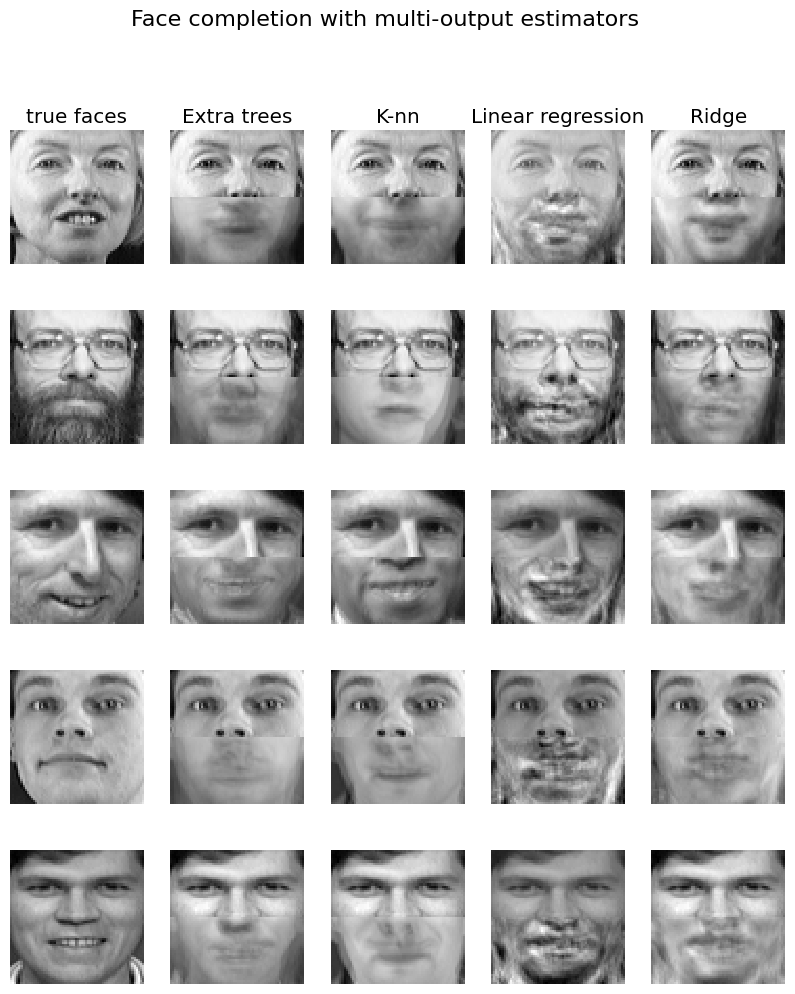

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_olivetti_faces
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.utils.validation import check_random_state

# Load the faces datasets
data, targets = fetch_olivetti_faces(return_X_y=True)

train = data[targets < 30]
test = data[targets >= 30]  # Test on independent people

# Test on a subset of people
n_faces = 5
rng = check_random_state(None)
face_ids = rng.randint(test.shape[0], size=(n_faces,))
test = test[face_ids, :]

n_pixels = data.shape[1]
# Upper half of the faces
X_train = train[:, : (n_pixels + 1) // 2]
# Lower half of the faces
y_train = train[:, n_pixels // 2 :]
X_test = test[:, : (n_pixels + 1) // 2]
y_test = test[:, n_pixels // 2 :]

# Fit estimators
ESTIMATORS = {
    "Extra trees": ExtraTreesRegressor(
        n_estimators=10, max_features=32, random_state=0
    ),
    "K-nn": KNeighborsRegressor(),
    "Linear regression": LinearRegression(),
    "Ridge": RidgeCV(),
}

y_test_predict = dict()
for name, estimator in ESTIMATORS.items():
    estimator.fit(X_train, y_train)
    y_test_predict[name] = estimator.predict(X_test)

# Plot the completed faces
image_shape = (64, 64)

n_cols = 1 + len(ESTIMATORS)
plt.figure(figsize=(2.0 * n_cols, 2.26 * n_faces))
plt.suptitle("Face completion with multi-output estimators", size=16)

for i in range(n_faces):
    true_face = np.hstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    for j, est in enumerate(sorted(ESTIMATORS)):
        completed_face = np.hstack((X_test[i], y_test_predict[est][i]))

        if i:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j)

        else:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j, title=est)

        sub.axis("off")
        sub.imshow(
            completed_face.reshape(image_shape),
            cmap=plt.cm.gray,
            interpolation="nearest",
        )

plt.show()

In [1]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


,sales,ad_spent
date,,
2022-01-01,8.830262,6.593897
2022-01-02,41.116283,2.503652
2022-01-03,NaN,0.000000
2022-01-04,32.968355,0.000000
2022-01-05,NaN,0.000000


% missing data in sales:  24.10958904109589


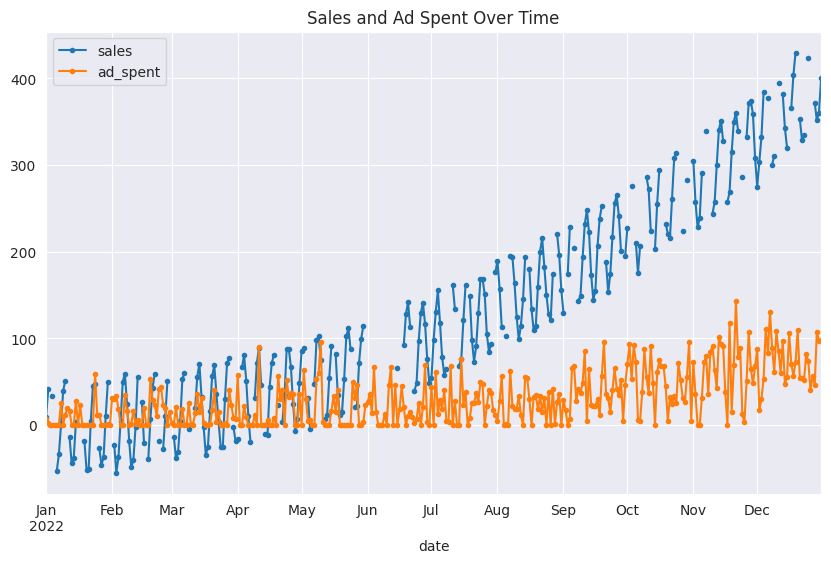

Correlation between sales and ad_spent:  0.6404423438597653


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL
from sklearn.impute import KNNImputer
import seaborn as sns

sns.set_style("darkgrid")
# Set the random seed for reproducibility
np.random.seed(0)

# Define the start date
start_date = datetime(2022, 1, 1)

# Generate dates for 365 days
dates = [start_date + timedelta(days=i) for i in range(365)]

# Generate more pronounced trend component (increasing linearly)
trend = np.power(np.linspace(0.1, 20, 365), 2)

# Generate more pronounced seasonal component (sinusoidal pattern) with weekly period
seasonal = 50 * np.sin(np.linspace(0, 2 * np.pi * 52, 365)) # 52 weeks in a year

# Generate random noise
noise = np.random.normal(0, 5, 365)

# Combine components to generate sales data
sales = trend + seasonal + noise

# Create ad_spent feature
# Using a scaled version of sales and adding more noise
ad_spent = 0.2 * sales + np.random.normal(0, 30, 365)  # Increased the noise and decreased the scale factor
ad_spent = np.maximum(ad_spent, 0)  # Making sure all ad_spent values are non-negative

# Create a dataframe
df = pd.DataFrame(
    {
        'date': dates,
        'sales': sales,
        'ad_spent': ad_spent
    }
)

# Set the date as the index
df.set_index('date', inplace=True)

# Generate missing values for a larger gap
for i in range(150, 165):  # A 15-day gap
    df.iloc[i, df.columns.get_loc('sales')] = np.nan

# Randomly choose indices for missing values (not including the already missing gap)
random_indices = random.sample(list(set(range(365)) - set(range(150,165))), int(0.20 * 365))

# Add random missing values
for i in random_indices:
    df.iloc[i, df.columns.get_loc('sales')] = np.nan

# Display the dataframe
display(df.head())

# Print the percentage of missing values 
print('% missing data in sales: ', 100*df['sales'].isnull().sum()/len(df))

# Plot the data
df[['sales', 'ad_spent']].plot(style='.-', figsize=(10,6), title='Sales and Ad Spent Over Time')
plt.show()

# Print correlation between sales and ad_spent
print("Correlation between sales and ad_spent: ", df['sales'].corr(df['ad_spent']))

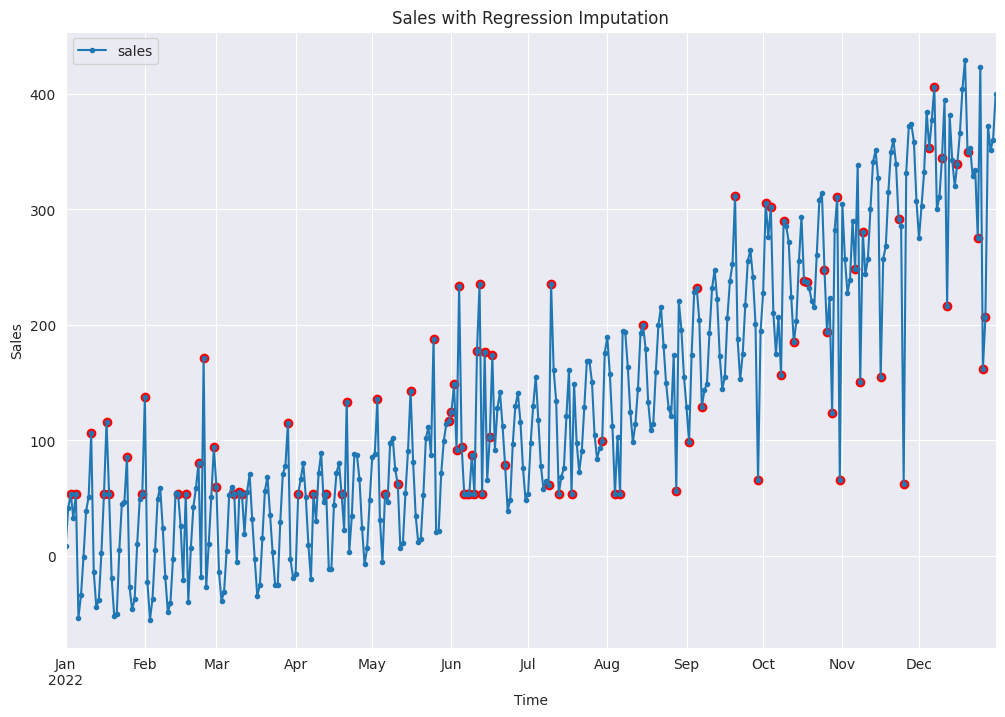

In [3]:
# Drop missing values to fit the regression model
df_imputed = df.copy()
df_non_missing = df.dropna()

# Instantiate the model
model = LinearRegression()

# Reshape data for model fitting (sklearn requires 2D array for predictors)
X = df_non_missing['ad_spent'].values.reshape(-1, 1)
Y = df_non_missing['sales'].values

# Fit the model
model.fit(X, Y)

# Get indices of missing sales
missing_sales_indices = df_imputed[df_imputed['sales'].isnull()].index

# Predict missing sales values
predicted_sales = model.predict(df_imputed.loc[missing_sales_indices, 'ad_spent'].values.reshape(-1, 1))

# Fill missing sales with predicted values
df_imputed.loc[missing_sales_indices, 'sales'] = predicted_sales

# Plot the main line with markers
df_imputed[['sales']].plot(style='.-', figsize=(12,8), title='Sales with Regression Imputation')

# Add points where data was imputed with red color
plt.scatter(missing_sales_indices, predicted_sales, color='red', label='Regression Imputation')

# Set labels
plt.xlabel('Time')
plt.ylabel('Sales')

plt.show()

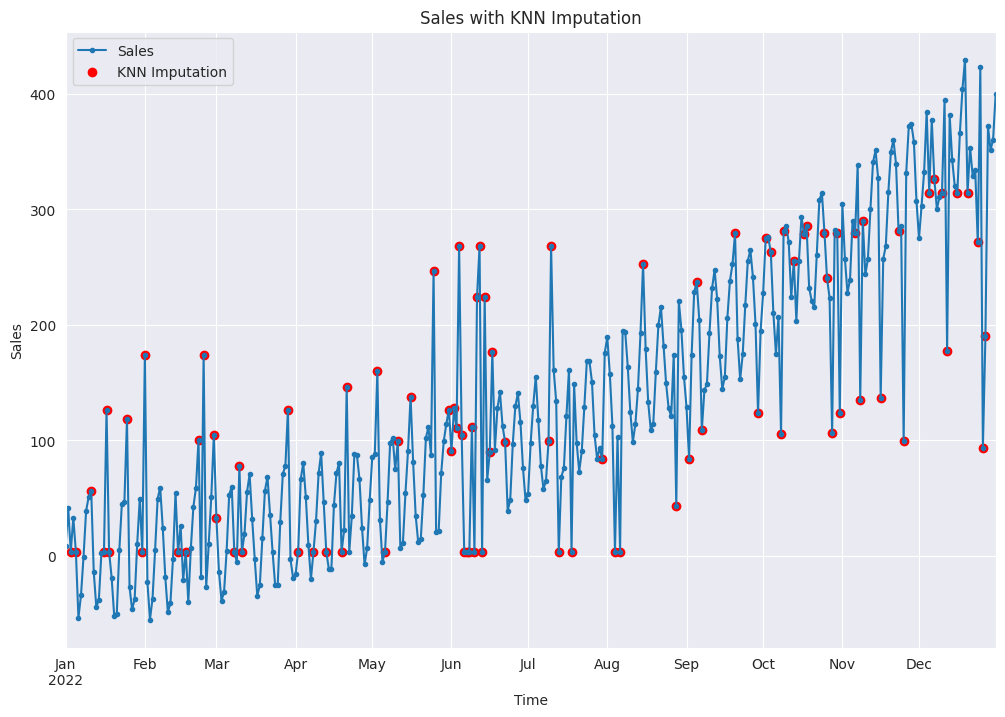

In [7]:
# Initialize the KNN imputer with k=5
imputer = KNNImputer(n_neighbors=10)

# Apply the KNN imputer
# Note: the KNNImputer requires 2D array-like input, hence the double brackets.
df_imputed = df.copy()
df_imputed[['sales', 'ad_spent']] = imputer.fit_transform(df_imputed[['sales', 'ad_spent']])

# Create a matplotlib plot
plt.figure(figsize=(12,8))
df_imputed['sales'].plot(style='.-', label='Sales')

# Add points where data was imputed
imputed_indices = df[df['sales'].isnull()].index
plt.scatter(imputed_indices, df_imputed.loc[imputed_indices, 'sales'], color='red', label='KNN Imputation')

# Set title and labels
plt.title('Sales with KNN Imputation')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()

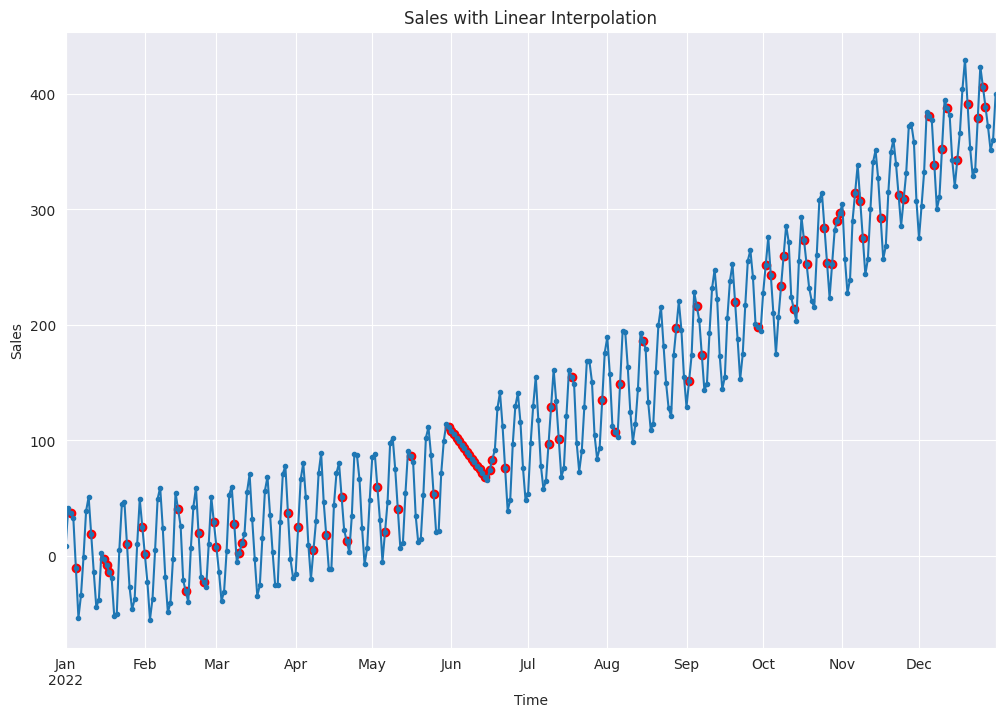

In [5]:
# Apply the linear interpolation method
df_imputed = df.interpolate(method ='linear', limit_direction ='forward')

# Plot the main line with markers
df_imputed['sales'].plot(style='.-', figsize=(12,8), title='Sales with Linear Interpolation')

# Add points where data was imputed with red color
imputed_indices = df[df['sales'].isnull()].index
plt.scatter(imputed_indices, df_imputed.loc[imputed_indices, 'sales'], color='red')

# Set labels
plt.xlabel('Time')
plt.ylabel('Sales')

plt.show()

